In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from torchvision.models import resnet18, ResNet18_Weights
res_model = resnet18(weights = ResNet18_Weights.DEFAULT)

In [4]:
for param in res_model.parameters():
    param.requires_grad = False

In [5]:
import torch.nn as nn

In [6]:
res_model.fc = nn.Linear(res_model.fc.in_features,2)

In [7]:
for param in res_model.layer4.parameters():
    param.requires_grad = True

In [8]:
import torch

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
res_model.load_state_dict(torch.load("/content/drive/MyDrive/models/model_1.pt",map_location = device))
res_model = res_model.to(device)

In [11]:
res_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
res_model.fc = nn.Identity()

In [13]:
res_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
dist_model_path = '/content/drive/MyDrive/results/checkpoint-366'

In [15]:
from transformers import DistilBertForSequenceClassification
dist_model = DistilBertForSequenceClassification.from_pretrained(dist_model_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [16]:
dist_model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [17]:
dist_model.dropout = nn.Identity()

In [18]:
dist_model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [19]:
csv_filepath = "/content/drive/MyDrive/new_data"

In [20]:
import os

In [21]:
train_df = pd.read_csv(os.path.join(csv_filepath,'new_train_df.csv'))
val_df = pd.read_csv(os.path.join(csv_filepath,'new_val_df.csv'))
test_df = pd.read_csv(os.path.join(csv_filepath,'new_test_df.csv'))

In [22]:
train_df['label'] = train_df['label'].map({
    'normal': 0,
    'abnormal': 1
})

val_df['label'] = val_df['label'].map({
    'normal': 0,
    'abnormal': 1
})

test_df['label'] = test_df['label'].map({
    'normal': 0,
    'abnormal': 1
})

In [23]:
from torchvision import transforms
import cv2
from PIL import Image

In [24]:
def train_transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomResizedCrop(size=224, scale=(0.9, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = Image.fromarray(img)
    img = transform(img)
    return img

In [25]:
def transform_pipeline(filepath):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = transform(img)
    return img

In [26]:
import os
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = hf_token
print("Hugging Face token successfully loaded!")

Hugging Face token successfully loaded!


In [27]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased",token = hf_token)

In [28]:
train_encodings = tokenizer(
    train_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

val_encodings = tokenizer(
    val_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

test_encodings = tokenizer(
    test_df['findings'].tolist(),
    padding = True,
    truncation = True,
    max_length = 512,
    return_tensors = 'pt'
)

In [29]:
class MultiModalDataset(torch.utils.data.Dataset):
      def __init__(self,df,filepath,transform_fn,encodings):
          self.df = df.reset_index(drop = True)
          self.filepath = filepath
          self.transform_fn = transform_fn
          self.encodings = encodings

      def __len__(self):
          return len(self.df)

      def __getitem__(self,index):
          img_path = os.path.join(self.filepath,self.df.loc[index,'filename'])
          img = self.transform_fn(img_path)

          item = {}
          for key, val in self.encodings.items():
              item[key] = val[index]

          label = self.df.loc[index,'label']

          return img, item, label

In [30]:
import torch.nn as nn

In [31]:
class MultiModalClass(nn.Module):
      def __init__(self,model_cnn,model_nlp,num_classes):
         super(MultiModalClass, self).__init__()
         self.model_cnn = model_cnn
         self.model_nlp = model_nlp

         self.classifier = nn.Sequential(
             nn.Linear(1280,512),
             nn.ReLU(),
             nn.Linear(512,num_classes)
         )

      def forward(self,image_input,text_input):
          features_cnn = self.model_cnn(image_input)
          outputs = self.model_nlp(**text_input)
          features_nlp = outputs.last_hidden_state[:,0,:]
          combined = torch.cat((features_cnn,features_nlp),dim = 1)
          return self.classifier(combined)


In [32]:
img_filepath = '/content/drive/MyDrive/required_images'

In [33]:
train_dataset = MultiModalDataset(train_df,img_filepath,train_transform_pipeline,train_encodings)
val_dataset = MultiModalDataset(val_df,img_filepath,transform_pipeline,val_encodings)
test_dataset = MultiModalDataset(test_df,img_filepath,transform_pipeline,test_encodings)

In [34]:
from torch.utils.data import DataLoader

In [35]:
train_loader = DataLoader(train_dataset,batch_size=16,shuffle=False,num_workers=2)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=False,num_workers=2)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=False,num_workers=2)


In [36]:
criterion = nn.CrossEntropyLoss()

In [37]:
import torch.optim as optim

In [38]:
text_encoder = dist_model.distilbert

In [39]:
model = MultiModalClass(res_model,text_encoder,2)

In [40]:
model.to(device)

MultiModalClass(
  (model_cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [41]:
model

MultiModalClass(
  (model_cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [42]:
for param in model.parameters():
    param.requires_grad = False

In [43]:
for param in model.classifier.parameters():
    param.requires_grad = True

In [44]:
optimizer = optim.Adam(model.parameters(),lr = 1e-3)

In [ ]:
for epoch in range(10):
    loss_train_list = list()
    loss_val_list = list()
    model.train()
    for batch_idx , (image , text, label) in enumerate(train_loader):
        optimizer.zero_grad()
        image = image.to(device)
        text = {k: v.to(device) for k, v in text.items()}
        outputs = model.forward(image,text)
        label = label.to(device)
        loss_train = criterion(outputs,label)
        loss_train.backward()
        loss_train_list.append(loss_train.item())
        optimizer.step()
    torch.save(model.state_dict(),f"/content/drive/MyDrive/multimodal/epoch_{epoch + 1}.pt")
    model.eval()
    for batch_idx , (image , text, label) in enumerate(val_loader):
        with torch.no_grad():
             image = image.to(device)
             text = {k: v.to(device) for k, v in text.items()}
             outputs = model.forward(image,text)
             label = label.to(device)
             loss_val = criterion(outputs,label)
             loss_val_list.append(loss_val.item())
    mean_train = sum(loss_train_list)/len(loss_train_list)
    mean_val = sum(loss_val_list)/len(loss_val_list)
    print(f"Epoch : {epoch + 1}, Train Loss : {mean_train:.4f}, Val Loss : {mean_val:.4f}")

In [46]:
model.load_state_dict(torch.load("/content/drive/MyDrive/multimodal/multimodal_1.pt",map_location = device))

<All keys matched successfully>

In [47]:
model.eval()

MultiModalClass(
  (model_cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [48]:
from sklearn.metrics import accuracy_score

all_preds = list()
all_labels = list()

model.eval()

with torch.inference_mode():
     for batch_idx , (image , text, label) in enumerate(test_loader):
         image = image.to(device)
         label = label.to(device)
         text = {k: v.to(device) for k, v in text.items()}
         outputs = model.forward(image,text)
         preds = outputs.argmax(dim=1)
         all_preds.extend(preds.cpu().numpy())
         all_labels.extend(label.cpu().numpy())

accuracy = accuracy_score(all_labels,all_preds)


In [49]:
accuracy

0.9754098360655737

In [50]:
from sklearn.metrics import classification_report,confusion_matrix

In [51]:
print(classification_report(all_labels,all_preds))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.98      0.98      0.98       194

    accuracy                           0.98       244
   macro avg       0.96      0.96      0.96       244
weighted avg       0.98      0.98      0.98       244



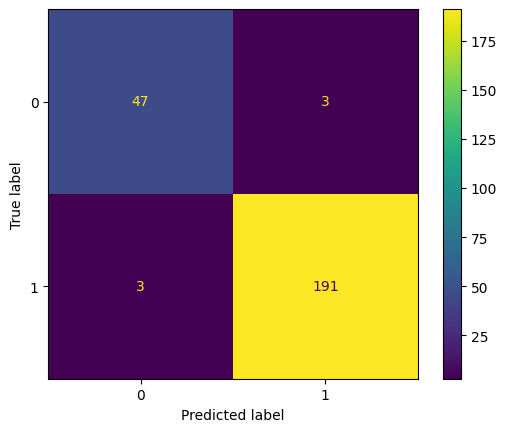

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(all_labels,all_preds)
plt.show()

In [53]:
from sklearn.metrics import roc_auc_score
ras = roc_auc_score(all_labels,all_preds)

In [54]:
ras

np.float64(0.9622680412371134)

In [55]:
from sklearn.metrics import roc_curve,auc,precision_recall_curve,average_precision_score

In [58]:
from sklearn.metrics import accuracy_score

all_probs = list()
all_labels = list()

model.eval()

with torch.inference_mode():
     for batch_idx , (image , text, label) in enumerate(test_loader):
         image = image.to(device)
         label = label.to(device)
         text = {k: v.to(device) for k, v in text.items()}
         outputs = model.forward(image,text)
         preds = outputs.softmax(dim=1)
         all_probs.extend(preds.cpu().numpy())
         all_labels.extend(label.cpu().numpy())


In [62]:
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

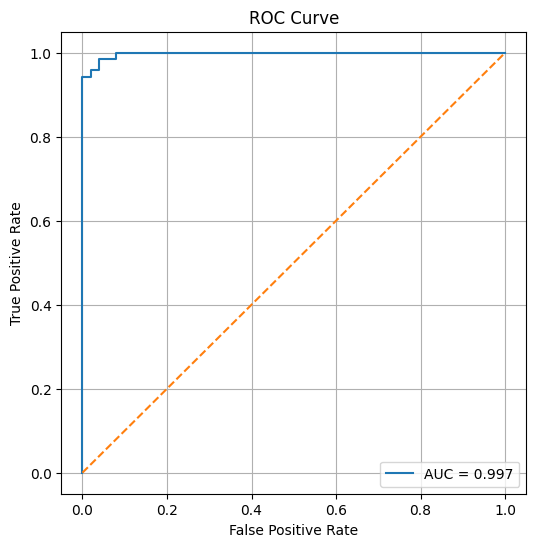

In [63]:
positive_probs = all_probs[:, 1]
fpr,tpr,thresholds = roc_curve(all_labels,positive_probs)
roc_auc = auc(fpr,tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

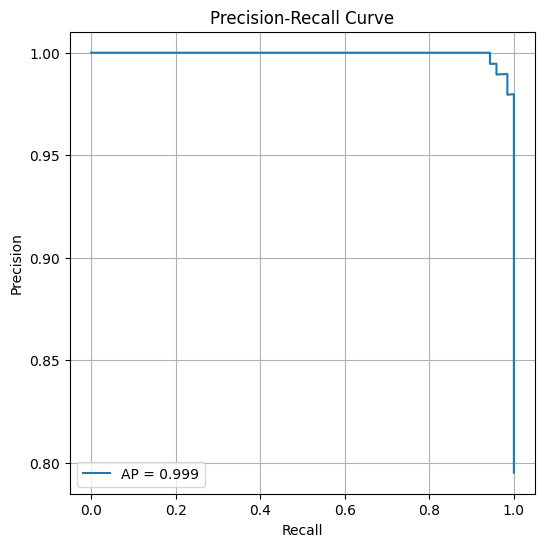

In [65]:
precision, recall, thresholds = precision_recall_curve(all_labels, positive_probs)
ap = average_precision_score(all_labels, positive_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()